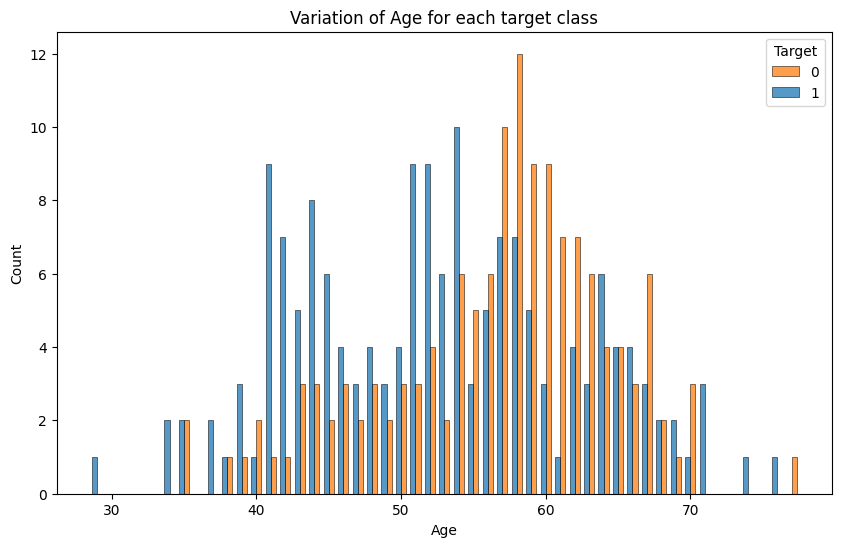

In [20]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Bài tập 1
cleveland_cvs_path = '/Users/macos/AIO/module 3 /w6/thứ 4 /Description/cleveland.csv'
df = pd.read_csv(cleveland_cvs_path, header = None)
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol',
              'fbs', 'restecg', 'thalach', 'exang',
              'oldpeak', 'slope', 'ca', 'thal', 'target']
df['target'] = df.target.map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
df['thal'] = df.thal.fillna(df.thal.mean())
df['ca'] = df.ca.fillna(df.ca.mean())

# distribution of target vs age

#.         Your code here ******************
plt.figure(figsize = (10,6)) # width , heights in inches 
sns.histplot(data = df , x = 'age' , hue = 'target' , multiple = 'dodge' , shrink = 0.7 , discrete = True)
plt.title('Variation of Age for each target class')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title = 'Target' , labels = ['0' , '1']) 
plt.show()

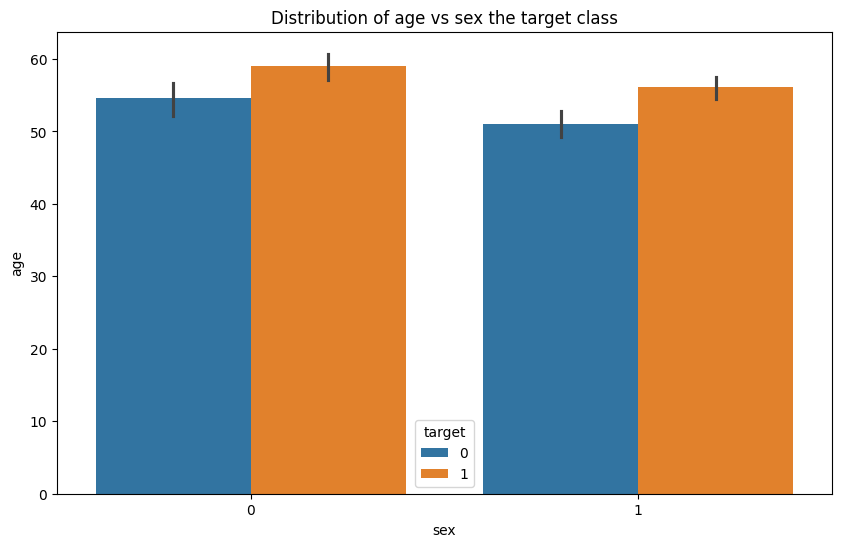

In [ ]:
# bai tap 2
# barplot of age vs sex with hue = target

#.         Your code here ******************
plt.figure(figsize = (10 , 6))
sns.barplot(data = df , x = 'sex' , y = 'age' , hue = 'target')
plt.title('Distribution of age vs sex the target class')
plt.show()

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

from sklearn.preprocessing import StandardScaler as ss
sc = ss()
X_train = sc.fit_transform(X_train) # chuẩn hoá học và biến đổi dữ liệu trên tập train 
X_test = sc.transform(X_test) # sử dụng các tham số học được từ tập train 

In [32]:
#########################################   KNeighborsClassifier   #############################################################
###############################################################################

#Bai tap 3
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
knn = KNeighborsClassifier(n_neighbors = 5 , weights = 'uniform' , algorithm = 'auto' , leaf_size = 30 , p = 2 , metric = 'minkowski')
knn.fit(X_train , y_train)

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)   

cm_train = confusion_matrix(y_train , y_train_pred)
cm_test = confusion_matrix(y_test , y_test_pred)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for KNeighborsClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for KNeighborsClassifier = {}'.format(accuracy_for_test))


Accuracy for training set for KNeighborsClassifier = 0.76
Accuracy for test set for KNeighborsClassifier = 0.69


In [35]:
#########################################   SVM   #############################################################
#Bai Tap 4
#.      Your code here ******************
from sklearn.svm import SVC
svm = SVC(kernel = 'rbf' , random_state = 42)
svm.fit(X_train , y_train)

y_train_pred_svm = svm.predict(X_train)
y_test_pred_svm = svm.predict(X_test)

cm_train = confusion_matrix(y_train , y_train_pred_svm)
cm_test = confusion_matrix(y_test , y_test_pred_svm)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for SVC = {}'.format(accuracy_for_train))
print('Accuracy for test set for SVC = {}'.format(accuracy_for_test))


Accuracy for training set for SVC = 0.66
Accuracy for test set for SVC = 0.67


In [ ]:
#########################################   Naive Bayes  #############################################################
# Bai tap 5

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************
gnb = GaussianNB()
gnb.fit(X_train , y_train)

y_train_gnb_pred = gnb.predict(X_train)
y_test_gnb_pred = gnb.predict(X_test)

cm_train = confusion_matrix(y_train , y_train_gnb_pred)
cm_test = confusion_matrix(y_test , y_test_gnb_pred)

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for GaussianNB = {}'.format(accuracy_for_train))
print('Accuracy for test set for GaussianNB = {}'.format(accuracy_for_test))



Accuracy for training set for GaussianNB = 0.85
Accuracy for test set for GaussianNB = 0.84


random state là một tham số dùng để kiểm soát tính ngẫu nhiên của thuật toán , đảm bảo kết quả có thể tái lập 

In [41]:
#########################################  Random Forest  #############################################################
#bai tap 7
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for RandomForestClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for RandomForestClassifier = {}'.format(accuracy_for_test))


Accuracy for training set for RandomForestClassifier = 0.85
Accuracy for test set for RandomForestClassifier = 0.84


In [ ]:
# bap tap 8
###############################################################################
# applying Adaboost


X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for AdaBoostClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for AdaBoostClassifier = {}'.format(accuracy_for_test))


Accuracy for training set for KNeighborsClassifier = 0.91
Accuracy for test set for KNeighborsClassifier = 0.84


In [ ]:
# Bai tap 9
###############################################################################
# Gradient Adaboost



X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#.         Your code here ******************

print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for GradientBoostingClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for GradientBoostingClassifier = {}'.format(accuracy_for_test))



Accuracy for training set for KNeighborsClassifier = 1.0
Accuracy for test set for KNeighborsClassifier = 0.85


In [ ]:
#bai tap 10
###############################################################################
# applying XGBoost



#.         Your code here ******************


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for XGBClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for XGBClassifier = {}'.format(accuracy_for_test))


Accuracy for training set for KNeighborsClassifier = 0.92
Accuracy for test set for KNeighborsClassifier = 0.84


In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

dtc =  DecisionTreeClassifier(random_state=42)
rfc = RandomForestClassifier(random_state=42)
knn =  KNeighborsClassifier()
xgb = XGBClassifier(XGBClassifier)
gc = GradientBoostingClassifier(random_state=42)
svc = SVC(kernel = 'rbf', random_state=42)
ad = AdaBoostClassifier(random_state=42)

#.         Your code here ******************


print()
accuracy_for_train = np.round((cm_train[0][0] + cm_train[1][1])/len(y_train),2)
accuracy_for_test = np.round((cm_test[0][0] + cm_test[1][1])/len(y_test),2)
print('Accuracy for training set for StackingClassifier = {}'.format(accuracy_for_train))
print('Accuracy for test set for StackingClassifier = {}'.format(accuracy_for_test))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:617: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)



Accuracy for training set for KNeighborsClassifier = 0.92
Accuracy for test set for KNeighborsClassifier = 0.9
